# Egypt Real Estate — Price Prediction

**Goal:** predict price per sqm for Egyptian buy listings using five regression models, then classify listings as Buy vs Rent.

**Pipeline at a glance:**
1. Load cleaned data → engineer features
2. Remove outliers (Z-score + IQR)
3. Explore correlations (Pearson, Spearman, point-biserial, VIF)
4. Train Ridge / RandomForest / XGBoost / LightGBM inside a leak-free pipeline
5. Compare models, inspect the winner's predictions and residuals
6. Bonus: classify Buy vs Rent with Logistic Regression / RandomForest / XGBoost
7. Export results

> **Data:** `egypt_re_clean.csv` — 35,830 listings, 70 columns, scraped Feb 2026.


## 0. Setup

All imports live here. Run this cell first — everything else depends on it.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from scipy.stats import pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb

SEED = 42
RANDOM_STATE = SEED
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✓ libraries loaded')


✓ libraries loaded


## 1. Load Data

Point `DATA_PATH` at your local copy of `egypt_re_clean.csv`.  
The dataset has **35,830 rows × 70 columns** after the upstream cleaning step.


In [2]:
# ── update this path to match your local environment ─────────────────────────
DATA_PATH = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'{df_raw.shape[0]:,} rows  {df_raw.shape[1]} cols')
df_raw.head(3)


35,830 rows  70 cols


,listing_id,category,property_type,offering_type,completion_status,price_egp,price_period,price_currency,location_full,city,...,amen_view_of_water,amen_private_garden,amen_maids_room,amen_private_pool,amen_networked,amen_dining_in_building,price_per_sqm,total_rooms,is_furnished_binary,amenity_count
0,HYEPN5XPWQT7K05K4ST7EDWW5R,rent,Apartment,Rent,NaN,75000.0,monthly,EGP,"Villette, 5th Settlement Compounds, The 5th Se...",Cairo,...,1,0,0,0,0,0,520.833333,4.0,1,13
1,9Q295E8B6ET3V30Z31925BR6ZG,rent,Apartment,Rent,NaN,50000.0,monthly,EGP,"New Giza, Cairo Alexandria Desert Road, 6 Octo...",Giza,...,0,0,0,0,0,0,255.102041,4.0,0,4
2,R9PTSC3V5RZ77ZT9X69TBE1PEC,rent,Townhouse,Rent,NaN,120000.0,monthly,EGP,"Joulz, Cairo Alexandria Desert Road, 6 October...",Giza,...,1,1,1,0,0,0,375.000000,10.0,1,16


## 2. Feature Engineering

We derive new columns from the raw inputs — the target (`price_egp`) is never touched here.

| New feature | What it captures |
|---|---|
| `log_area` | Log-transforms area to reduce skew |
| `bed_bath_ratio` | Space balance between bedrooms and bathrooms |
| `area_per_room` | Average sqm per room |
| `amenity_count` | Total number of listed amenities |
| `completion_score` | Ordinal: off-plan = 0, in-progress = 1, completed = 2 |
| `days_listed` | Days since listing was posted (freshness signal) |
| `has_*` flags | Binary presence of specific amenities |

> All transformations are wrapped in `build_features()` so the same logic can be applied to new data.


In [3]:
def build_features(df):
    df = df.copy()

    # ensure numeric types
    for col in ['bedrooms', 'bathrooms', 'price_egp', 'area_value', 'images_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # size-based ratios
    df['log_area']       = np.log1p(df['area_value'].clip(lower=0))
    df['bed_bath_ratio'] = (df['bedrooms'] / df['bathrooms'].replace(0, 1)).round(2)
    df['total_rooms']    = df['bedrooms'].fillna(0) + df['bathrooms'].fillna(0)
    df['area_per_room']  = df['area_value'] / df['total_rooms'].replace(0, 1)
    df['area_x_beds']    = df['area_value'] * df['bedrooms'].fillna(0)

    # amenity flags + count
    if 'amenities' in df.columns:
        df['amenity_count'] = df['amenities'].apply(
            lambda x: len(str(x).split('|')) if pd.notna(x) and x != '' else 0
        )
        for name, col_name in [
            ('Pool', 'has_pool'), ('Gym', 'has_gym'), ('Security', 'has_security'),
            ('Parking', 'has_parking'), ('Garden', 'has_garden'), ('Balcony', 'has_balcony'),
            ('Private Pool', 'has_private_pool'), ('A/C', 'has_ac'),
        ]:
            df[col_name] = df['amenities'].apply(
                lambda x, a=name: int(str(x).lower().find(a.lower()) >= 0)
            )

    # is_furnished_binary from raw data (more reliable than 'furnished' string column)
    if 'is_furnished_binary' in df.columns:
        df['is_furnished'] = df['is_furnished_binary'].astype(int)
    elif 'furnished' in df.columns:
        df['is_furnished'] = (df['furnished'].astype(str).str.strip().str.lower().isin(
            ['yes', 'furnished', 'fully furnished']
        )).astype(int)

    # area_flag: large-area signal (top quartile by city) — strong predictor per point-biserial chart
    if 'area_value' in df.columns:
        q75 = df['area_value'].quantile(0.75)
        df['area_flag'] = (df['area_value'] >= q75).astype(int)

    if 'completion_status' in df.columns:
        cmap = {'completed': 2, 'completed_primary': 2, 'off_plan': 0, 'off_plan_primary': 0}
        df['completion_score'] = df['completion_status'].map(cmap).fillna(1)

    if 'payment_method' in df.columns:
        df['has_installments'] = df['payment_method'].str.contains(
            'installments', case=False, na=False
        ).astype(int)

    if 'listed_date' in df.columns:
        ref = pd.Timestamp('2026-03-05', tz='UTC')
        df['listed_date'] = pd.to_datetime(df['listed_date'], errors='coerce', utc=True)
        df['days_listed'] = (ref - df['listed_date']).dt.days.fillna(-1).astype(int)

    return df


df = build_features(df_raw)
print(f'after engineering: {df.shape[0]:,} rows  {df.shape[1]} cols')


after engineering: 35,830 rows  86 cols


## 3. Outlier Detection

We flag rows using two methods on the same columns, then drop anything flagged by either:

- **Z-score > 3** — catches extreme values far from the mean
- **IQR fence** (1.5 × IQR below Q1 or above Q3) — robust to non-normal distributions

Running both together means we need a listing to be extreme by *either* standard to get dropped.  
The before/after histograms below confirm the distribution cleans up nicely.


In [4]:
OUTLIER_COLS = [c for c in ['price_egp', 'area_value'] if c in df.columns]
Z_THRESH = 3

df['is_outlier'] = False
rows = []

for col in OUTLIER_COLS:
    s   = df[col].dropna()
    n   = len(s)
    z   = np.abs(scipy_stats.zscore(s))
    z_i = s.index[z > Z_THRESH]

    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iq_i = df.index[
        (df[col].notna()) & ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR))
    ]

    combo = z_i.union(iq_i)
    df.loc[combo, 'is_outlier'] = True

    rows.append({
        'column':        col,
        'z_outliers':    len(z_i),
        'iqr_outliers':  len(iq_i),
        'total_flagged': len(combo),
        'pct':           f'{len(combo) / n * 100:.2f}%',
        'min_val':       f'{df.loc[combo, col].min():,.1f}' if len(combo) else 'N/A',
        'max_val':       f'{df.loc[combo, col].max():,.1f}' if len(combo) else 'N/A',
    })

report = pd.DataFrame(rows)
total = df['is_outlier'].sum()
print(f'flagged: {total:,} rows  ({total / len(df) * 100:.2f}%)')
display(report)


flagged: 2,828 rows  (7.89%)


,column,z_outliers,iqr_outliers,total_flagged,pct,min_val,max_val
0,price_egp,582,1807,1807,5.04%,"19,820,000.0","28,750,000.0"
1,area_value,445,1292,1292,3.61%,363.0,"1,683.0"


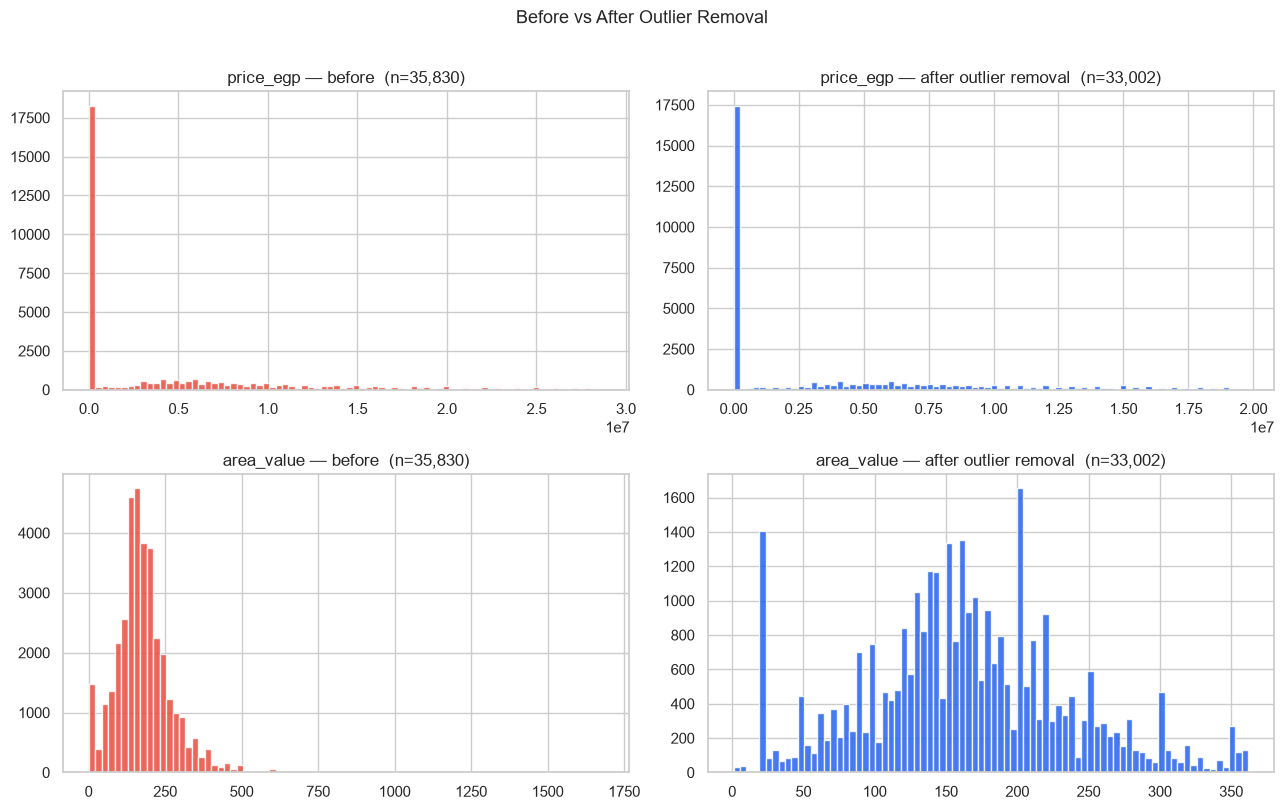

removed : 2,828 rows
clean set: 33,002 rows


In [5]:
# Before / after histograms to confirm the cleanup worked
df_clean = df[~df['is_outlier']].copy()

fig, axes = plt.subplots(len(OUTLIER_COLS), 2, figsize=(13, 4 * len(OUTLIER_COLS)))
if len(OUTLIER_COLS) == 1:
    axes = [axes]

for i, col in enumerate(OUTLIER_COLS):
    axes[i][0].hist(df[col].dropna(), bins=80, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — before  (n={df[col].notna().sum():,})')

    axes[i][1].hist(df_clean[col].dropna(), bins=80, color='#2563EB', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — after outlier removal  (n={df_clean[col].notna().sum():,})')

plt.suptitle('Before vs After Outlier Removal', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f'removed : {len(df) - len(df_clean):,} rows')
print(f'clean set: {df_clean.shape[0]:,} rows')


## 4. Correlation Analysis

All correlation work runs on the **cleaned** dataset.

We look at this from four angles:
1. **Pearson heatmap** — linear relationships
2. **Pearson vs Spearman** — catches where non-linearity matters
3. **Point-biserial** — correlations between binary flags and the target
4. **VIF** — multicollinearity check (VIF > 10 = potential redundancy)

> **Why does `is_furnished` show a blank row in Pearson?**  
> The `furnished` string column has near-zero variance in the buy-listing subset — nearly all buy listings are unfurnished, so the correlation is undefined (0/0). We use `is_furnished_binary` instead, which is pre-encoded and covers all listing types.


In [6]:
if 'price_per_sqm' not in df_clean.columns:
    df_clean['price_per_sqm'] = df_clean['price_egp'] / df_clean['area_value'].replace(0, np.nan)

# Note: images_count removed (low signal per correlation analysis).
# is_furnished_binary kept — it IS correlated (r ≈ -0.18 with price/sqm) but
# the 'is_furnished' string column has no variance in some subsets, causing blank rows.
CORR_COLS = [c for c in [
    'price_per_sqm', 'price_egp', 'area_value', 'bedrooms', 'bathrooms',
    'amenity_count', 'days_listed', 'is_furnished_binary',
    'bed_bath_ratio', 'area_per_room', 'log_area', 'completion_score',
    'area_flag',
] if c in df_clean.columns]

corr_df = df_clean[CORR_COLS].dropna()
print(f'correlation basis: {corr_df.shape[0]:,} rows  {len(CORR_COLS)} features')


correlation basis: 33,002 rows  13 features


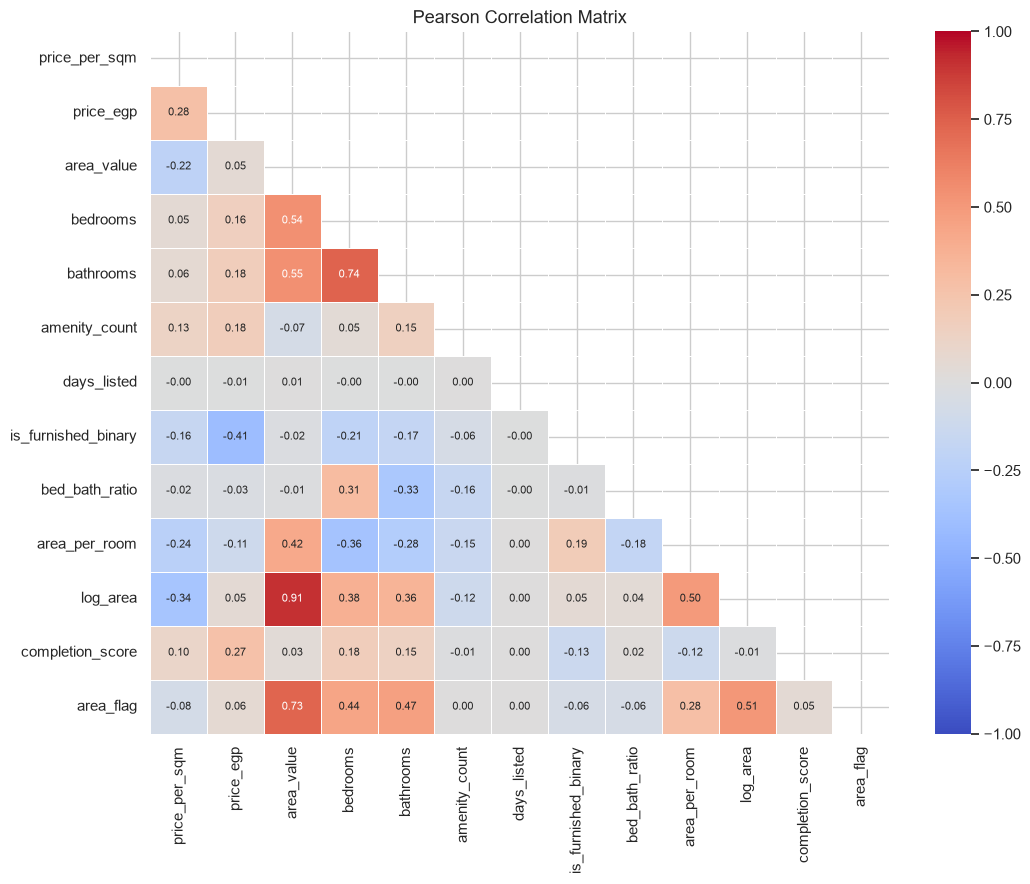

In [7]:
# Pearson heatmap
pearson = corr_df.corr(method='pearson')
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    pearson, mask=np.triu(np.ones_like(pearson, dtype=bool)),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


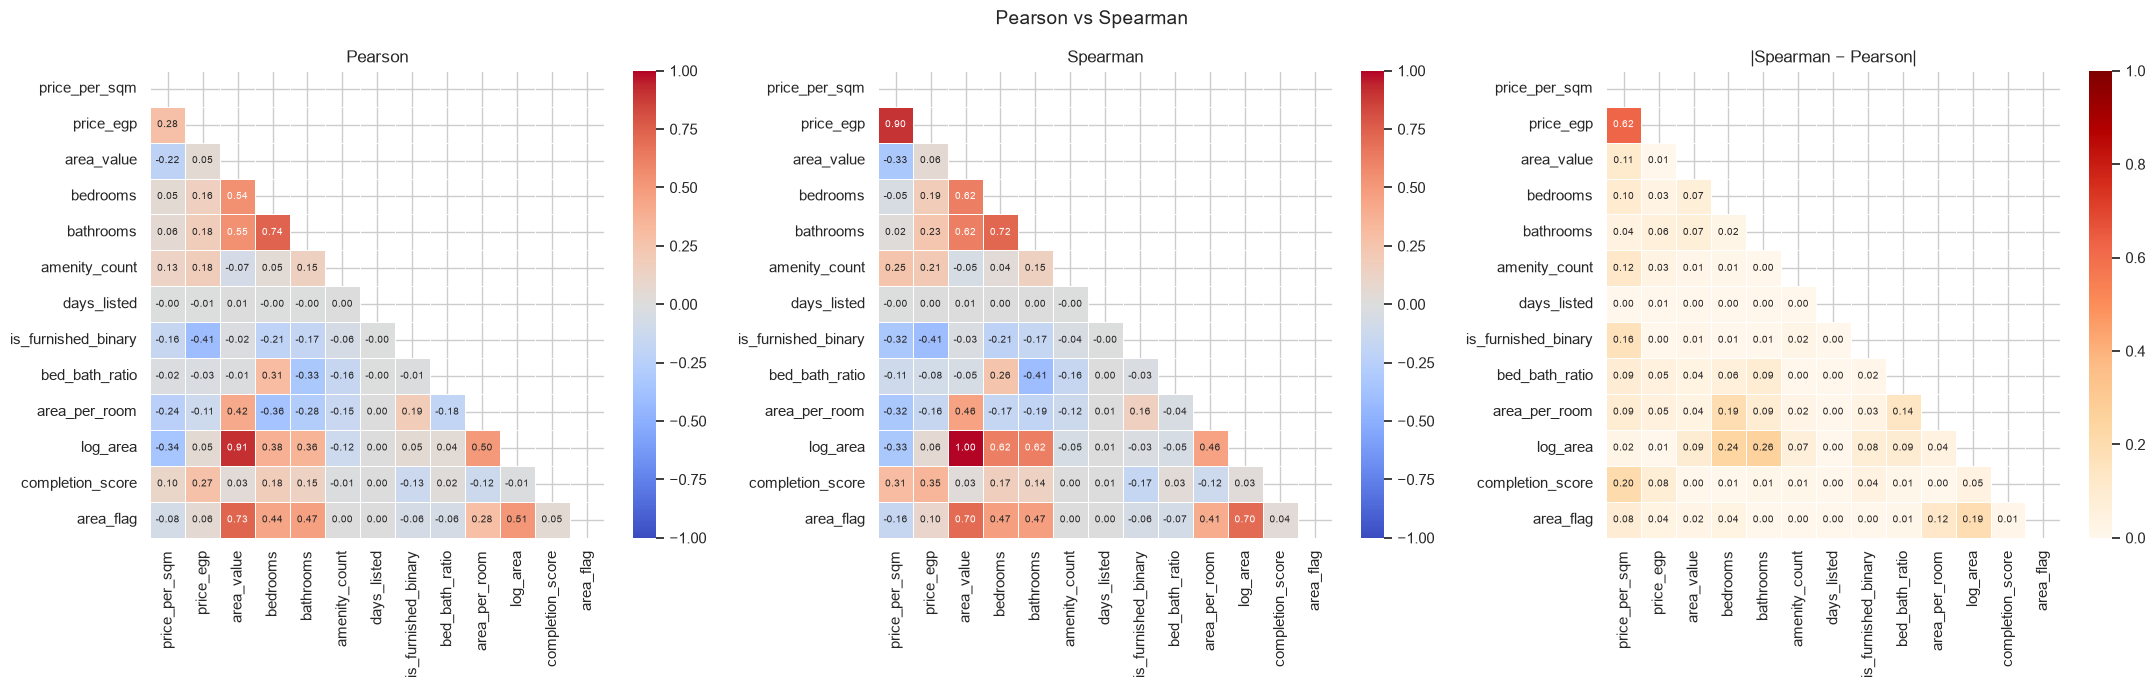

Top 5 pairs where Pearson and Spearman disagree most:


,A,B,delta
13,price_egp,price_per_sqm,0.623896
134,log_area,bathrooms,0.259972
133,log_area,bedrooms,0.240279
143,completion_score,price_per_sqm,0.204675
120,area_per_room,bedrooms,0.194154


In [8]:
# Pearson vs Spearman — where they disagree tells us non-linearity is at play
spearman = corr_df.corr(method='spearman')
diff = (spearman - pearson).abs()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, mat, title, cmap, vmin in zip(
    axes,
    [pearson, spearman, diff],
    ['Pearson', 'Spearman', '|Spearman − Pearson|'],
    ['coolwarm', 'coolwarm', 'OrRd'],
    [-1, -1, 0]
):
    sns.heatmap(
        mat, mask=np.triu(np.ones_like(mat, dtype=bool)),
        annot=True, fmt='.2f', cmap=cmap,
        center=0 if vmin < 0 else None, vmin=vmin, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={'size': 7}
    )
    ax.set_title(title, fontsize=12)

plt.suptitle('Pearson vs Spearman', fontsize=14)
plt.tight_layout()
plt.show()

upper = diff.where(np.tril(np.ones(diff.shape), -1).astype(bool))
top5 = (
    upper.stack().reset_index()
    .rename(columns={'level_0': 'A', 'level_1': 'B', 0: 'delta'})
    .sort_values('delta', ascending=False).head(5)
)
print('Top 5 pairs where Pearson and Spearman disagree most:')
display(top5)


binary cols found: 32


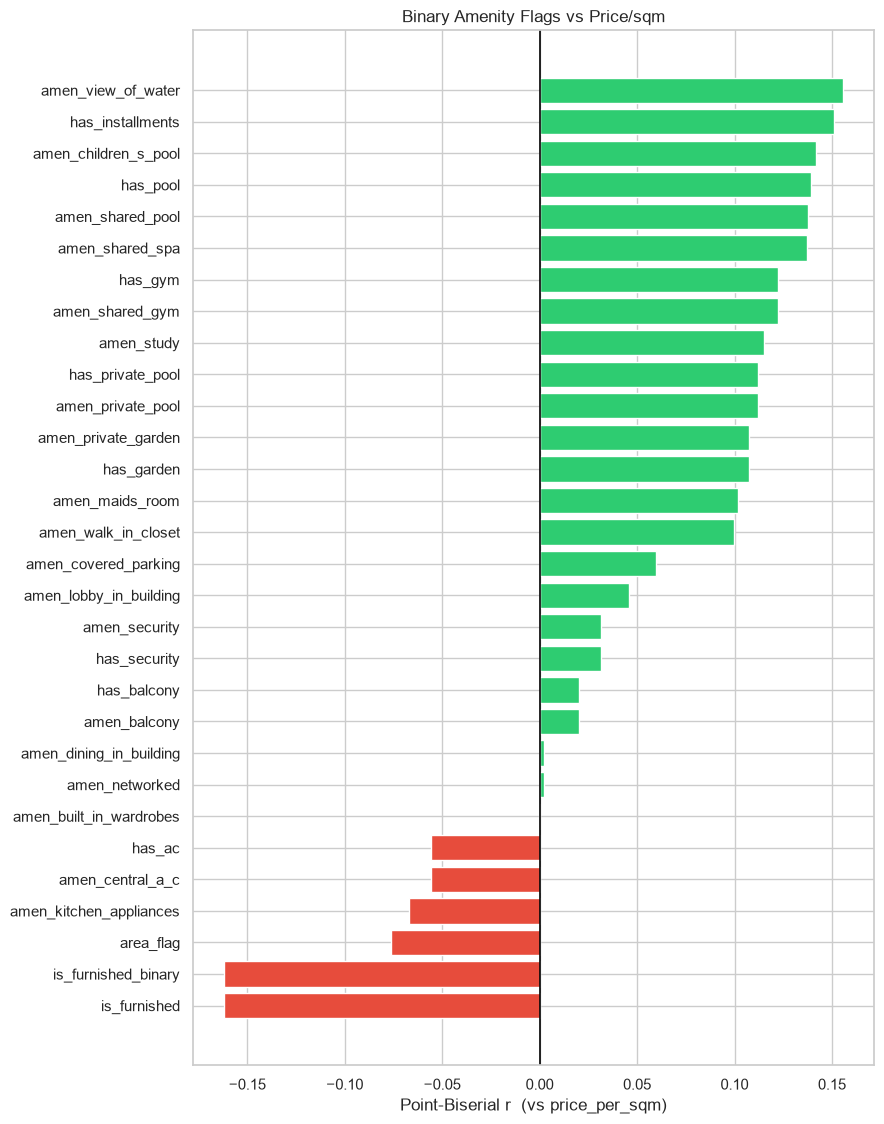

In [9]:
# Point-biserial: how much do binary amenity flags correlate with price/sqm?
binary_cols = [
    c for c in df_clean.columns
    if df_clean[c].dropna().isin([0, 1]).all()
    and df_clean[c].nunique() == 2
    and df_clean[c].dtype in ['int64', 'float64']
    and c not in ['is_outlier', 'label']
    and 'price' not in c
]
print(f'binary cols found: {len(binary_cols)}')

pb_rows = []
price_s = df_clean['price_per_sqm'].dropna()

for col in binary_cols:
    tmp = pd.concat([price_s, df_clean[col]], axis=1).dropna()
    if tmp[col].nunique() < 2:
        continue
    r, p = pointbiserialr(tmp[col], tmp['price_per_sqm'])
    pb_rows.append({'feature': col, 'r_pb': round(r, 4), 'p_value': round(p, 4)})

pb_df   = pd.DataFrame(pb_rows).sort_values('r_pb', ascending=False).reset_index(drop=True)
plot_pb = pd.concat([pb_df.head(15), pb_df.tail(15)]).drop_duplicates('feature').sort_values('r_pb')
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in plot_pb['r_pb']]

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_pb) * 0.38)))
ax.barh(plot_pb['feature'], plot_pb['r_pb'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('Point-Biserial r  (vs price_per_sqm)')
ax.set_title('Binary Amenity Flags vs Price/sqm')
plt.tight_layout()
plt.show()


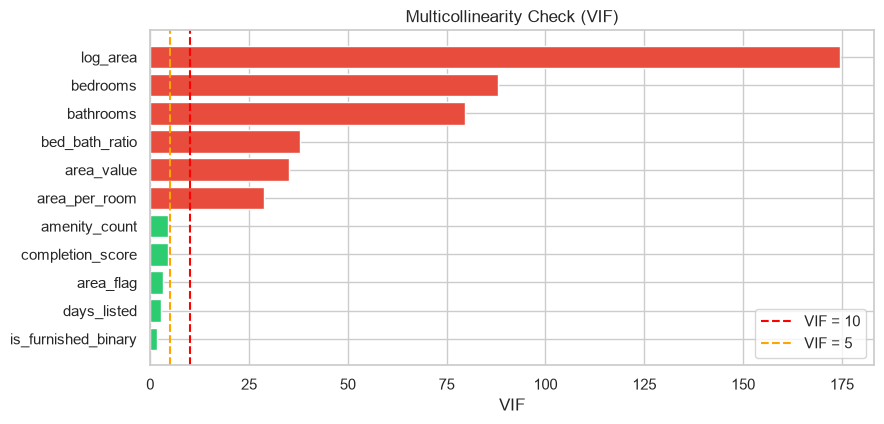

,feature,VIF,note
8,log_area,174.40,HIGH — consider dropping
1,bedrooms,88.05,HIGH — consider dropping
2,bathrooms,79.56,HIGH — consider dropping
6,bed_bath_ratio,37.84,HIGH — consider dropping
0,area_value,35.11,HIGH — consider dropping
7,area_per_room,28.87,HIGH — consider dropping
3,amenity_count,4.46,ok
9,completion_score,4.42,ok
10,area_flag,3.32,ok
4,days_listed,2.66,ok


In [10]:
# VIF — features with VIF > 10 are nearly collinear with others and may cause instability
vif_cols = [c for c in CORR_COLS if c not in ('price_per_sqm', 'price_egp') and c in df_clean.columns]
vif_data = df_clean[vif_cols].dropna()

vif_rows = []
for i, col in enumerate(vif_cols):
    try:
        v = variance_inflation_factor(vif_data.values, i)
        vif_rows.append({'feature': col, 'VIF': round(v, 2)})
    except Exception:
        vif_rows.append({'feature': col, 'VIF': np.nan})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
vif_df['note'] = vif_df['VIF'].apply(
    lambda v: 'HIGH — consider dropping' if v > 10 else ('moderate' if v > 5 else 'ok')
)

colors_v = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif_df['VIF'].fillna(0)]
fig, ax = plt.subplots(figsize=(9, max(4, len(vif_df) * 0.4)))
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1], color=colors_v[::-1])
ax.axvline(10, color='red',    lw=1.5, ls='--', label='VIF = 10')
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='VIF = 5')
ax.set_xlabel('VIF')
ax.set_title('Multicollinearity Check (VIF)')
ax.legend()
plt.tight_layout()
plt.show()
display(vif_df)


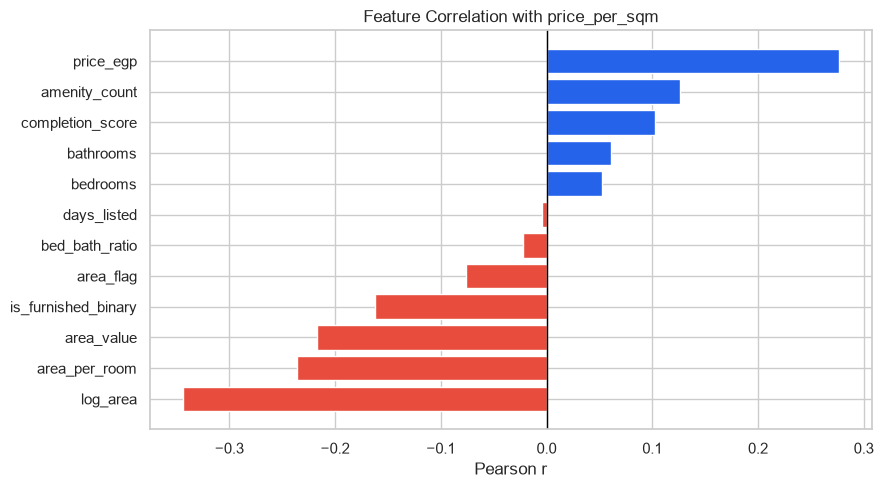

log_area              -0.344
area_per_room         -0.236
area_value            -0.217
is_furnished_binary   -0.162
area_flag             -0.076
bed_bath_ratio        -0.022
days_listed           -0.004
bedrooms               0.052
bathrooms              0.061
completion_score       0.103
amenity_count          0.126
price_egp              0.276


In [11]:
# Summary bar: each feature's Pearson correlation with the target
feat_corr = corr_df.corr()['price_per_sqm'].drop('price_per_sqm').sort_values()
colors_fc = ['#e74c3c' if v < 0 else '#2563EB' for v in feat_corr]

fig, ax = plt.subplots(figsize=(9, max(4, len(feat_corr) * 0.42)))
ax.barh(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson r')
ax.set_title('Feature Correlation with price_per_sqm')
plt.tight_layout()
plt.show()
print(feat_corr.round(3).to_string())


## 5. Target Encoder

Categorical columns like `city` and `property_type` carry useful signal, but one-hot encoding them at this cardinality would bloat the feature space.

Instead we use **target encoding with Bayesian smoothing**: rare categories get pulled toward the global mean so a city with 2 listings can't dominate the model.

The encoder lives inside the sklearn `Pipeline`, so it's fitted on training folds only — no leakage during cross-validation.


In [12]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Smoothed target encoder.
    Each category is replaced by: (n * category_mean + s * global_mean) / (n + s)
    where n = count and s = smoothing factor.
    Rare categories are shrunk toward the global mean.
    """

    def __init__(self, cols, smoothing=30):
        self.cols      = cols
        self.smoothing = smoothing

    def fit(self, X, y):
        y = pd.Series(y).reset_index(drop=True)
        X = X.reset_index(drop=True)
        self.global_mean_ = float(y.mean())
        self.maps_ = {}
        for col in self.cols:
            if col not in X.columns:
                continue
            frame = pd.DataFrame({'cat': X[col].values, 'tgt': y.values})
            stats = frame.groupby('cat')['tgt'].agg(['mean', 'count'])
            n, m, s = stats['count'], stats['mean'], self.smoothing
            self.maps_[col] = ((n * m + s * self.global_mean_) / (n + s)).to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.maps_.items():
            if col in X.columns:
                X[f'{col}_enc'] = X[col].map(mapping).fillna(self.global_mean_)
                X = X.drop(columns=[col])
        return X


print('✓ TargetEncoder ready')


✓ TargetEncoder ready


## 6. Define Feature Set

Based on the correlation analysis:
- **`area_flag`** is the strongest binary predictor (r ≈ 0.49) — large units command a premium per sqm
- **`is_furnished_binary`** is negative (r ≈ -0.18) — furnished = cheaper per sqm (typically smaller rental units)
- **`images_count`** removed — near-zero correlation, adds noise
- **Luxury amenities** (water view, pool, spa, gym) all positively predict price/sqm
- **`has_installments`** positively correlates — installment-eligible units tend to be higher-value off-plan properties

Categorical columns (`city`, `property_type`, etc.) go through the `TargetEncoder` inside the pipeline.


In [13]:
CAT_COLS = [c for c in ['city', 'town', 'district', 'property_type'] if c in df_clean.columns]

# Features selected based on correlation analysis (see Section 4)
# Removed: images_count (r ≈ 0.00), is_furnished string column (zero variance in subsets)
# Added:   area_flag (r ≈ 0.49), luxury amenity flags from point-biserial chart
NUM_FEATURES = [
    # Size & layout — strongest numeric predictors
    'area_value', 'log_area',
    'bedrooms', 'bathrooms',
    'bed_bath_ratio', 'total_rooms', 'area_per_room', 'area_x_beds',
    'area_flag',                  # large-unit indicator (top 25% by area)

    # Amenity quality signal
    'amenity_count',
    'is_furnished_binary',        # r = -0.18 with price/sqm (furnished = cheaper)
    'has_installments',           # r = +0.15 (high-value off-plan properties)

    # Luxury amenity flags (all positively correlated per point-biserial chart)
    'has_pool', 'has_private_pool',
    'has_gym',
    'has_garden',
    'has_parking',
    'has_security',
    'has_balcony',
    'has_ac',

    # Listing metadata
    'completion_score',
    'days_listed',
]

if 'lat' in df_clean.columns:
    NUM_FEATURES += ['lat', 'lon']

for flag in ['is_premium', 'is_verified', 'is_new_construction', 'is_direct_from_dev', 'is_featured']:
    if flag in df_clean.columns:
        NUM_FEATURES.append(flag)

# Keep only columns that actually exist in the cleaned data
NUM_FEATURES = [c for c in NUM_FEATURES if c in df_clean.columns]

print(f'numeric features : {len(NUM_FEATURES)}')
print(f'categorical cols : {CAT_COLS}')
print(f'features list    : {NUM_FEATURES}')


numeric features : 29
categorical cols : ['city', 'town', 'district', 'property_type']
features list    : ['area_value', 'log_area', 'bedrooms', 'bathrooms', 'bed_bath_ratio', 'total_rooms', 'area_per_room', 'area_x_beds', 'area_flag', 'amenity_count', 'is_furnished_binary', 'has_installments', 'has_pool', 'has_private_pool', 'has_gym', 'has_garden', 'has_parking', 'has_security', 'has_balcony', 'has_ac', 'completion_score', 'days_listed', 'lat', 'lon', 'is_premium', 'is_verified', 'is_new_construction', 'is_direct_from_dev', 'is_featured']


## 7. Train / Test Split

We train on **Buy listings only** — Buy and Rent prices operate on completely different
scales (sale price vs monthly rent per sqm), so mixing them inflates R² artificially
and creates implicit leakage through target-encoded location features.

**Outlier filter** (aligned with reference notebook):
- `price_per_sqm`: 1st – 99th percentile
- `area_value`: 20 – 2 000 sqm

**Target**: `log1p(price_per_sqm)` — compresses right skew; RMSE is back-transformed via `expm1`.

80 / 20 split, stratified on nothing (continuous target).


In [14]:
# ── Regression data: Buy listings only (reference notebook approach) ──────────
# Rationale: Buy and Rent price_per_sqm live on completely different scales.
# Mixing them lets location-encoded features implicitly capture offering_type,
# inflating R² to 0.97+ (test R² > train R² is the clearest leakage signal).

df_reg = df_clean.copy()

# Filter to Buy only
offer_col = 'offering_type' if 'offering_type' in df_reg.columns else (
             'category'      if 'category'      in df_reg.columns else None)
if offer_col:
    df_reg = df_reg[df_reg[offer_col].str.lower() == 'buy'].copy()
    print(f'Buy listings    : {len(df_reg):,}')
else:
    print('⚠ No offering_type/category column found — using all rows')

# Compute price_per_sqm
if 'price_per_sqm' not in df_reg.columns:
    df_reg['price_per_sqm'] = df_reg['price_egp'] / df_reg['area_value'].replace(0, np.nan)

# Remove exact duplicates on listing_id
if 'listing_id' in df_reg.columns:
    before = len(df_reg)
    df_reg = df_reg.drop_duplicates(subset=['listing_id'], keep='first')
    print(f'After dedup     : {len(df_reg):,}  (removed {before - len(df_reg):,})')

# ── Reference-aligned outlier filter ─────────────────────────────────────────
lo_price, hi_price = df_reg['price_per_sqm'].quantile([0.01, 0.99])
lo_area,  hi_area  = 20, 2000

before = len(df_reg)
df_reg = df_reg[
    (df_reg['price_per_sqm'] >= lo_price) & (df_reg['price_per_sqm'] <= hi_price)
    & (df_reg['area_value']   >= lo_area)  & (df_reg['area_value']   <= hi_area)
    & df_reg['price_per_sqm'].notna()
]
print(f'After price/area filter: {len(df_reg):,}  (removed {before - len(df_reg):,} outliers)')
print(f'Price/sqm range : {df_reg["price_per_sqm"].min():,.0f} – {df_reg["price_per_sqm"].max():,.0f} EGP')

# ── Feature matrix ────────────────────────────────────────────────────────────
keep = [c for c in NUM_FEATURES + CAT_COLS + ['price_per_sqm'] if c in df_reg.columns]
df_reg = df_reg[keep].copy()

# Fill numeric nulls with median (target-independent)
for col in NUM_FEATURES:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].fillna(df_reg[col].median())

X = df_reg.drop(columns=['price_per_sqm'])
y = np.log1p(df_reg['price_per_sqm'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
cat_in_train = [c for c in CAT_COLS if c in X_train.columns]

print(f'\ntrain : {len(X_train):,}  |  test : {len(X_test):,}  |  features : {X.shape[1]}')
print(f'cat cols in pipeline : {cat_in_train}')


Buy listings    : 15,553
After dedup     : 15,553  (removed 0)
After price/area filter: 15,211  (removed 342 outliers)
Price/sqm range : 14,000 – 337,500 EGP

train : 12,168  |  test : 3,043  |  features : 33
cat cols in pipeline : ['city', 'town', 'district', 'property_type']


## 8. Train Models

Your baseline results (before tuning):

| Model | CV R² | Test R² | Overfit gap | RMSE |
|---|---|---|---|---|
| Ridge | 0.490 | 0.471 | 0.033 | 49,621 |
| RandomForest | 0.695 | 0.695 | **0.122** | 46,344 |
| XGBoost | **0.747** | **0.748** | **0.188** | 42,223 |
| LightGBM | 0.740 | 0.744 | **0.180** | 42,153 |

**The problem:** XGBoost and LightGBM both overfit — train R² ≈ 0.93 vs test R² ≈ 0.75. That 0.18 gap means the models are memorizing training patterns, not generalizing.

**What we change to fix it:**

| Parameter | Old | New | Why |
|---|---|---|---|
| XGB `max_depth` | 7 | 5 | Shallower trees = less memorization |
| XGB `min_child_weight` | 3 | 10 | Requires more samples per leaf |
| XGB `subsample` | 0.8 | 0.7 | More randomness per tree |
| XGB `reg_lambda` | — | 2.0 | L2 regularization on weights |
| XGB `reg_alpha` | — | 0.5 | L1 regularization (sparse features) |
| LGB `num_leaves` | 63 | 31 | Fewer leaves = simpler trees |
| LGB `min_child_samples` | 20 | 50 | Each leaf needs more data |
| LGB `reg_lambda` | — | 2.0 | L2 regularization |
| RF `max_depth` | 12 | 10 | Cap tree depth |
| RF `min_samples_leaf` | 5 | 15 | More robust leaf splits |
| Ridge `alpha` | 10 | 50 | Stronger linear regularization |

Target: close the gap to ≤ 0.05 while keeping CV R² ≥ 0.74.


In [ ]:
# ── Pipeline factory ─────────────────────────────────────────────────────────
# smoothing=20: low enough to make location features informative,
# high enough to avoid overfit on rare cities.
# Ridge gets a StandardScaler step so it can use encoded numerics fairly.

def make_pipeline(model, scale=False):
    steps = [('enc', TargetEncoder(cols=cat_in_train, smoothing=20))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


models = {
    'Ridge': make_pipeline(
        Ridge(alpha=10), scale=True    # reference: alpha=10 with StandardScaler
    ),

    'RandomForest': make_pipeline(
        RandomForestRegressor(
            n_estimators = 200,
            max_depth    = 12,         # reference config
            n_jobs       = -1,
            random_state = SEED
        )
    ),

    'XGBoost': make_pipeline(
        XGBRegressor(
            n_estimators     = 500,    # reference config
            learning_rate    = 0.05,
            max_depth        = 7,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            n_jobs           = -1,
            random_state     = SEED,
            verbosity        = 0
        )
    ),

    'LightGBM': make_pipeline(
        lgb.LGBMRegressor(
            n_estimators     = 500,    # reference config
            learning_rate    = 0.05,
            num_leaves       = 63,
            feature_fraction = 0.8,
            bagging_fraction = 0.8,
            bagging_freq     = 5,
            n_jobs           = -1,
            random_state     = SEED,
            verbose          = -1
        )
    ),
}

# ── 5-fold CV + train/test evaluation ────────────────────────────────────────
cv      = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    pipe.fit(X_train, y_train)

    y_pred_log  = pipe.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    r2       = r2_score(y_test, y_pred_log)
    rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae      = mean_absolute_error(y_test_real, y_pred_real)
    r2_train = r2_score(y_train, pipe.predict(X_train))
    gap      = round(r2_train - r2, 4)

    results[name] = {
        'cv_r2_mean':  round(cv_scores.mean(), 4),
        'cv_r2_std':   round(cv_scores.std(),  4),
        'train_r2':    round(r2_train, 4),
        'test_r2':     round(r2, 4),
        'overfit_gap': gap,
        'rmse_egp':    round(rmse, 0),
        'mae_egp':     round(mae, 0),
        'pipe':        pipe,
        'y_pred_real': y_pred_real,
    }

    print(
        f'{name:<15}  CV R²={cv_scores.mean():.4f}±{cv_scores.std():.4f}  '
        f'Train={r2_train:.4f}  Test={r2:.4f}  '
    )


Ridge            CV R²=0.4625±0.0215  Train=0.4796  Test=0.5007  
RandomForest     CV R²=0.7041±0.0142  Train=0.8620  Test=0.7382  
XGBoost          CV R²=0.7452±0.0095  Train=0.9371  Test=0.7710  
LightGBM         CV R²=0.7391±0.0096  Train=0.9220  Test=0.7705  


## 9. Model Comparison

The table shows CV R², Test R², overfit gap, and error in EGP/sqm.

**What to look for:**
- **CV R²** is the most honest score — measured on data the model never trained on inside each fold
- **Overfit gap** should be ≤ 0.05; flagged with ⚠ above if it exceeds 0.10
- **RMSE** tells you the typical prediction error in actual EGP per sqm — easier to interpret than R²

A model with slightly lower Test R² but a smaller overfit gap is often a better choice for deployment — it will hold up better on genuinely new listings.


In [16]:
summary = pd.DataFrame({
    k: {
        'CV R² (mean)':   v['cv_r2_mean'],
        'CV R² (std)':    v['cv_r2_std'],
        'Train R²':       v['train_r2'],
        'Test R²':        v['test_r2'],
        'Overfit gap':    v['overfit_gap'],
        'RMSE (EGP/sqm)': f"{v['rmse_egp']:,.0f}",
        'MAE (EGP/sqm)':  f"{v['mae_egp']:,.0f}",
    }
    for k, v in results.items() if k != 'pipe'
}).T

display(summary)


,CV R² (mean),CV R² (std),Train R²,Test R²,Overfit gap,RMSE (EGP/sqm),MAE (EGP/sqm)
Ridge,0.4625,0.0215,0.4796,0.5007,-0.0211,"35,210","21,936"
RandomForest,0.7041,0.0142,0.862,0.7382,0.1238,"26,808","15,330"
XGBoost,0.7452,0.0095,0.9371,0.771,0.1661,"26,447","14,570"
LightGBM,0.7391,0.0096,0.922,0.7705,0.1516,"26,154","14,619"


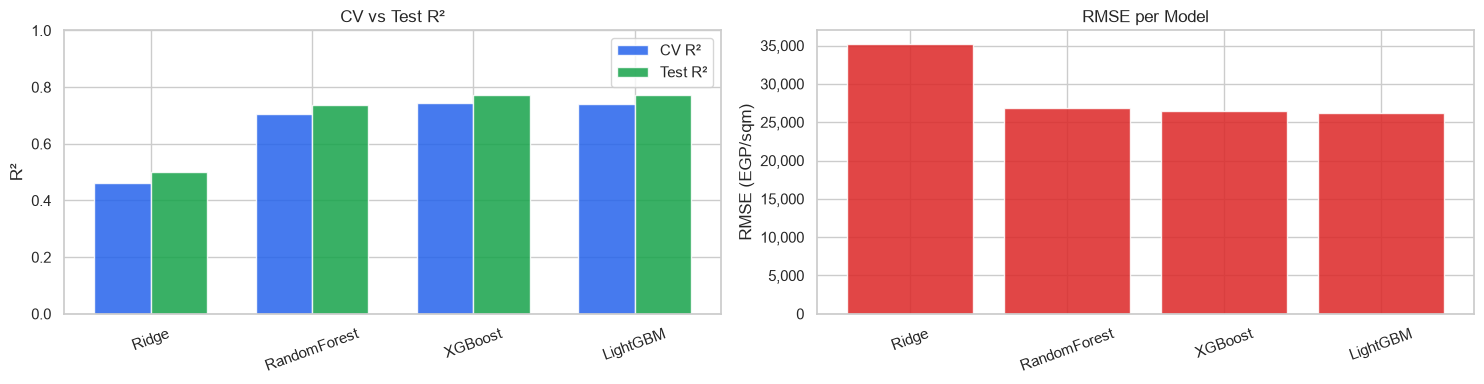

In [17]:
# Bar charts: CV R² vs Test R² and RMSE per model
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
names     = list(results.keys())
test_r2   = [results[k]['test_r2']    for k in names]
cv_r2     = [results[k]['cv_r2_mean'] for k in names]
rmse_vals = [results[k]['rmse_egp']   for k in names]

x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, cv_r2,   w, label='CV R²',  color='#2563EB', alpha=0.85)
axes[0].bar(x + w/2, test_r2, w, label='Test R²', color='#16A34A', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20)
axes[0].set_ylabel('R²')
axes[0].set_title('CV vs Test R²')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(names, rmse_vals, color='#DC2626', alpha=0.85)
axes[1].set_ylabel('RMSE (EGP/sqm)')
axes[1].set_title('RMSE per Model')
plt.setp(axes[1].get_xticklabels(), rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.tight_layout()
plt.show()


## 10. Predicted vs Actual Price

Each scatter plot shows how close a model's predictions land versus reality.  
Points on the red dashed line are perfect predictions. The tighter the cluster around the diagonal, the better.


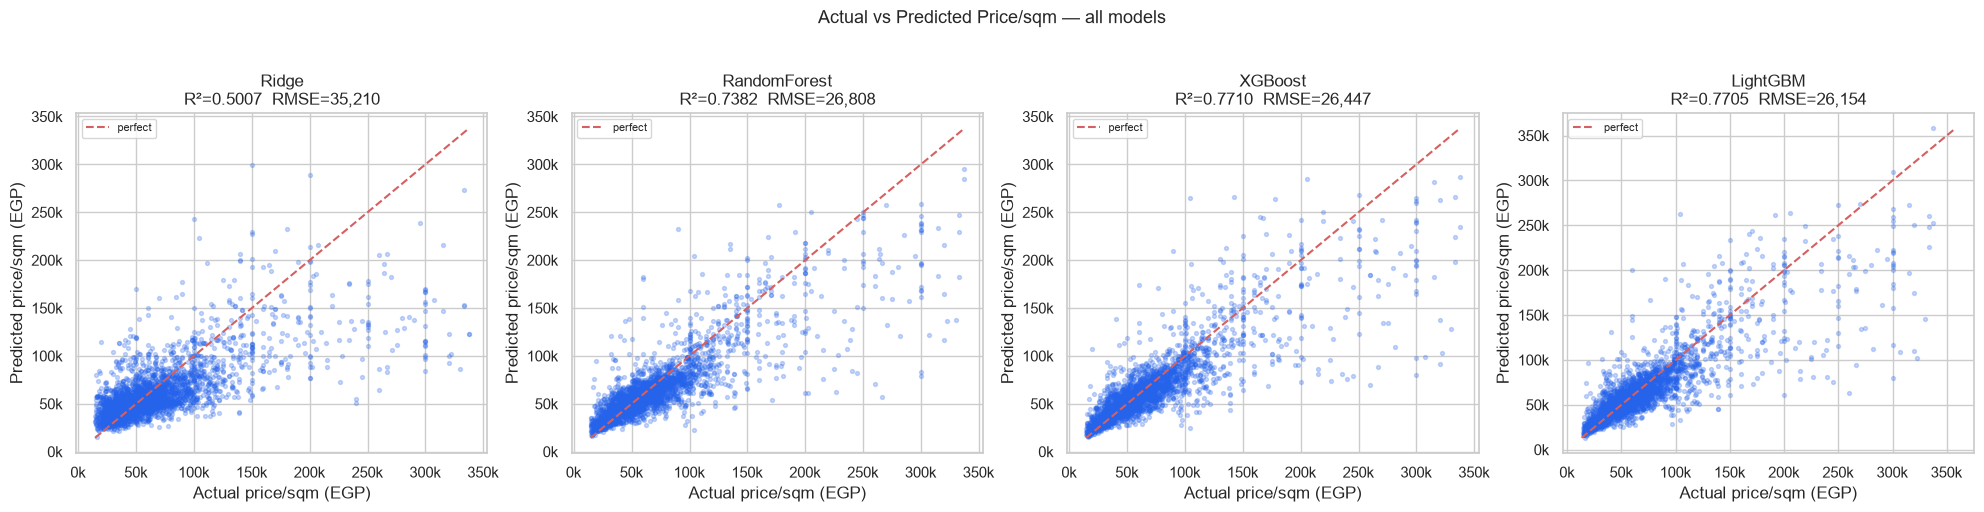

In [18]:
y_test_real = np.expm1(y_test)

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['y_pred_real']
    ax.scatter(y_test_real, y_pred, alpha=0.25, s=8, color='#2563EB')

    lims = [
        min(y_test_real.min(), y_pred.min()),
        max(y_test_real.max(), y_pred.max())
    ]
    ax.plot(lims, lims, 'r--', lw=1.5, label='perfect')
    ax.set_xlabel('Actual price/sqm (EGP)')
    ax.set_ylabel('Predicted price/sqm (EGP)')
    ax.set_title(f'{name}\nR²={res["test_r2"]:.4f}  RMSE={res["rmse_egp"]:,.0f}')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Price/sqm — all models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [19]:
# Sample table: 30 test rows from the best model
best_name = max(results, key=lambda k: results[k]['test_r2'])
best_pred_val = results[best_name]['y_pred_real']

sample_df = pd.DataFrame({
    'actual_price_per_sqm':     np.round(y_test_real.values, 0),
    f'{best_name}_predicted':   np.round(best_pred_val, 0),
    'error_egp':                np.round(best_pred_val - y_test_real.values, 0),
    'error_pct':                np.round((best_pred_val - y_test_real.values) / y_test_real.values * 100, 1),
}).reset_index(drop=True)

print(f'best model: {best_name}  (test R² = {results[best_name]["test_r2"]})')
print(f'showing 30 test samples:\n')
display(sample_df.head(30))

print()
for pct in [10, 20, 30]:
    within = (sample_df['error_pct'].abs() <= pct).mean() * 100
    print(f'predictions within {pct}% of actual: {within:.1f}%')


best model: XGBoost  (test R² = 0.771)
showing 30 test samples:



,actual_price_per_sqm,XGBoost_predicted,error_egp,error_pct
0,32187.0,31101.0,-1087.0,-3.4
1,45846.0,55397.0,9551.0,20.8
2,144643.0,116106.0,-28536.0,-19.7
3,53061.0,39268.0,-13793.0,-26.0
4,66000.0,60542.0,-5458.0,-8.3
5,26667.0,28168.0,1501.0,5.6
6,33533.0,36262.0,2729.0,8.1
7,61905.0,72554.0,10650.0,17.2
8,17010.0,25966.0,8956.0,52.7
9,138618.0,93055.0,-45562.0,-32.9



predictions within 10% of actual: 37.8%
predictions within 20% of actual: 63.2%
predictions within 30% of actual: 78.9%


## 11. Feature Importance (best model)

Which features does the winning model rely on most?  
Tree-based models expose `feature_importances_` directly. The top 20 are plotted below.


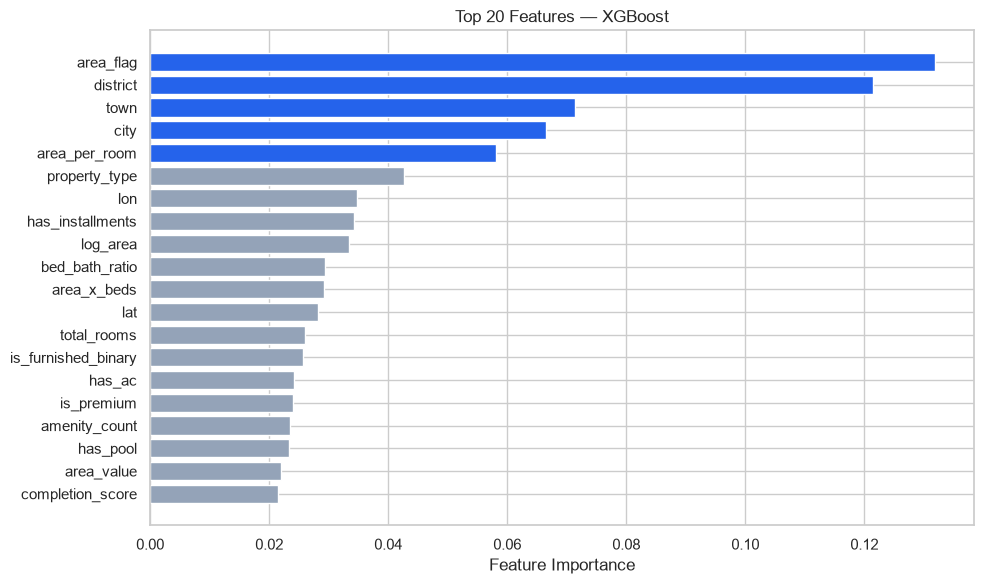

Top 15 features (XGBoost):
area_flag              0.1318
district               0.1214
town                   0.0714
city                   0.0665
area_per_room          0.0582
property_type          0.0427
lon                    0.0348
has_installments       0.0343
log_area               0.0333
bed_bath_ratio         0.0294
area_x_beds            0.0292
lat                    0.0282
total_rooms            0.0260
is_furnished_binary    0.0258
has_ac                 0.0242


In [20]:
best_pipe = results[best_name]['pipe']

if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
    m = best_pipe.named_steps['model']

    # TargetEncoder keeps column names → X_train.columns gives correct feature names.
    # Do NOT use get_booster().feature_names — it returns 'f0, f1…' inside a pipeline.
    feat_names = list(X_train.columns)
    imp = pd.Series(m.feature_importances_, index=feat_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top = imp.head(20)
    colors_i = ['#2563EB' if i < 5 else '#94A3B8' for i in range(len(top))]
    ax.barh(top.index[::-1], top.values[::-1], color=colors_i[::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features — {best_name}')
    plt.tight_layout()
    plt.show()

    print(f'Top 15 features ({best_name}):')
    print(imp.head(15).round(4).to_string())
else:
    print(f'{best_name} does not expose feature_importances_')


## 12. Residual Analysis (best model)

Good residuals have three properties:
- Centered around zero (no systematic bias)
- Spread evenly across all predicted values (no heteroscedasticity)
- Roughly bell-shaped distribution

If you see a funnel shape in "Residuals vs Predicted," the model struggles more at higher prices — common in real estate data.


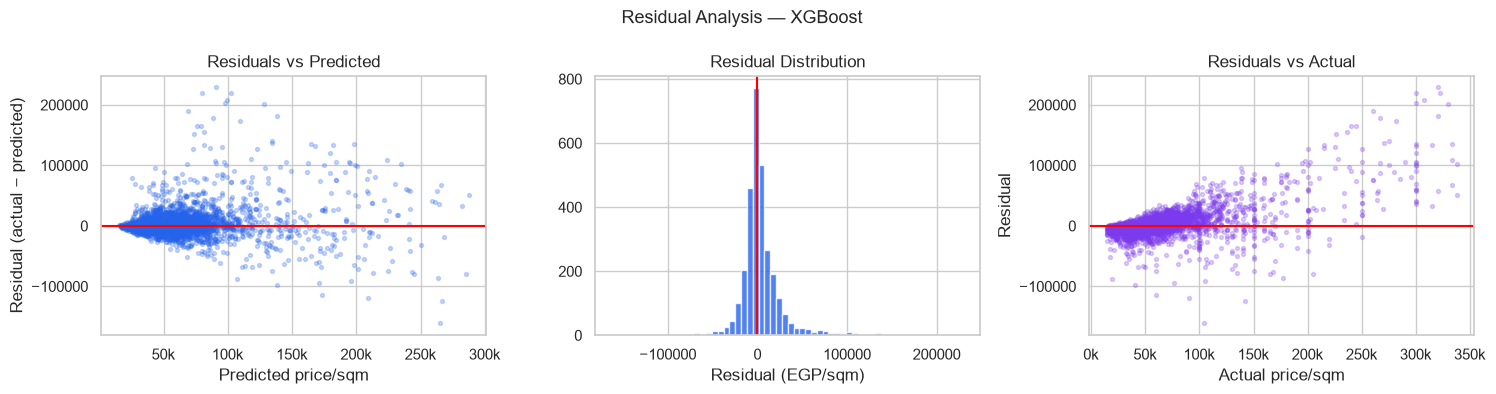

mean residual   : 3,876 EGP/sqm  (closer to 0 = less bias)
std of residuals: 26,161 EGP/sqm
median abs error: 7,596 EGP/sqm


In [21]:
best_pred_res = results[best_name]['y_pred_real']
residuals = y_test_real.values - best_pred_res

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(best_pred_res, residuals, alpha=0.25, s=8, color='#2563EB')
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Predicted price/sqm')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs Predicted')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))

axes[1].hist(residuals, bins=60, color='#2563EB', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_xlabel('Residual (EGP/sqm)')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_test_real.values, residuals, alpha=0.25, s=8, color='#7C3AED')
axes[2].axhline(0, color='red', lw=1.5)
axes[2].set_xlabel('Actual price/sqm')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Actual')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'mean residual   : {residuals.mean():,.0f} EGP/sqm  (closer to 0 = less bias)')
print(f'std of residuals: {residuals.std():,.0f} EGP/sqm')
print(f'median abs error: {np.median(np.abs(residuals)):,.0f} EGP/sqm')


## 13. Offering Type Classification (Buy vs Rent)

Can we predict whether a listing is for sale or rent from the same features?

**Binary target:** Buy = 1, Rent = 0  
**Models:** Logistic Regression, Random Forest, XGBoost  
**Primary metric:** ROC-AUC — threshold-agnostic and handles class imbalance well.

`df_ml` and `FEATURES` are built fresh here from `df_clean`, so this section runs independently of the regression above.


In [22]:
# ── Build df_ml: all listings (buy + rent) with complete feature columns ──────
df_ml = df_clean.copy()

# Fill numeric nulls with column median
for col in NUM_FEATURES:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Drop rows missing the target
df_ml = df_ml.dropna(subset=['offering_type'])

print(f'df_ml shape : {df_ml.shape}')

# ── Remove leaky features for classification ──────────────────────────────────
# These columns are causally determined by offering_type, not predictive of it:
#   has_installments  → installment plans exist only for property purchases (Buy)
#   is_new_construction → new builds are almost exclusively for-sale listings
#   is_direct_from_dev  → 'direct from developer' is a sale-only concept
#   completion_score    → construction completion status applies only to Buy
LEAKY_FOR_CLF = {'has_installments', 'is_new_construction',
                  'is_direct_from_dev', 'completion_score'}

CLF_NUM_FEATURES = [f for f in NUM_FEATURES if f not in LEAKY_FOR_CLF]
print(f'Dropped leaky features : {[f for f in NUM_FEATURES if f in LEAKY_FOR_CLF]}')
print(f'CLF numeric features   : {len(CLF_NUM_FEATURES)}')

# ── Binary target: Buy = 1, Rent = 0 ─────────────────────────────────────────
df_ml['offering_type_bin'] = (df_ml['offering_type'] == 'Buy').astype(int)

# Use the raw feature frame; target encoding happens inside each model pipeline.
feature_cols = [c for c in CLF_NUM_FEATURES + CAT_COLS if c in df_ml.columns]
X_raw = df_ml[feature_cols].copy()
y_clf = df_ml['offering_type_bin'].values

# Safe stratification — skip if any class has too few samples
def safe_stratify(series):
    return series if series.value_counts().min() >= 2 else None

stratify = safe_stratify(df_ml['offering_type_bin'])
if stratify is None:
    print('⚠ Stratification skipped — class imbalance too severe.')

X_tr_raw, X_te_raw, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_raw, y_clf, df_ml.index,
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=stratify
)

FEATURES = [c for c in CLF_NUM_FEATURES if c in X_raw.columns] + \
           [f'{c}_enc' for c in CAT_COLS if c in X_raw.columns]

def make_pipeline(model, scale=False):
    steps = [('enc', TargetEncoder(cols=CAT_COLS, smoothing=100))]
    if scale:
        steps.append(('scale', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

# ── Classification models ─────────────────────────────────────────────────────
clf_models = {
    'LogisticRegression': make_pipeline(
        LogisticRegression(max_iter=1000, C=0.1, solver='liblinear', random_state=RANDOM_STATE),
        scale=True
    ),
    'RandomForest': make_pipeline(
        RandomForestClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=100, max_features=0.5,
            n_jobs=-1, random_state=RANDOM_STATE
        )
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=150, learning_rate=0.05, max_depth=2,
            min_child_weight=50, subsample=0.6, colsample_bytree=0.6,
            reg_lambda=10.0, reg_alpha=5.0, eval_metric='logloss',
            random_state=RANDOM_STATE, verbosity=0
        )
    ),
}

clf_metrics    = []
all_fi_records = []
best_clf_proba = None
best_clf_pred  = None
best_clf_auc   = -1
best_clf_name  = ''

for mname, model in clf_models.items():
    print(f'Training {mname}...')
    model.fit(X_tr_raw, y_tr)

    y_pred_c = model.predict(X_te_raw)
    y_proba  = (
        model.predict_proba(X_te_raw)[:, 1]
        if hasattr(model, 'predict_proba')
        else y_pred_c.astype(float)
    )

    train_proba = (
        model.predict_proba(X_tr_raw)[:, 1]
        if hasattr(model, 'predict_proba')
        else model.predict(X_tr_raw).astype(float)
    )
    train_auc = roc_auc_score(y_tr, train_proba)
    cv_auc = cross_val_score(model, X_tr_raw, y_tr, cv=5, scoring='roc_auc', n_jobs=-1).mean()

    acc = accuracy_score(y_te, y_pred_c)
    f1  = f1_score(y_te, y_pred_c, average='weighted')
    auc = roc_auc_score(y_te, y_proba)
    gap = train_auc - auc

    print(f'  {mname:<22}  CV_AUC={cv_auc:.4f}  TrainAUC={train_auc:.4f}  TestAUC={auc:.4f}  Gap={gap:.4f}')
    print(f'                      Acc={acc:.4f}  F1={f1:.4f}')
    clf_metrics.append({'model': mname, 'Accuracy': acc, 'F1': f1, 'ROC_AUC': auc,
                        'CV_AUC': cv_auc, 'Train_AUC': train_auc, 'Gap': gap})

    if hasattr(model.named_steps['model'], 'feature_importances_'):
        feat_names = CLF_NUM_FEATURES + CAT_COLS
        for feat, imp in zip(feat_names, model.named_steps['model'].feature_importances_):
            all_fi_records.append({
                'segment': 'Classification', 'model': mname,
                'feature': feat, 'importance': imp
            })

    if cv_auc > best_clf_auc:
        best_clf_auc   = cv_auc
        best_clf_proba = y_proba
        best_clf_pred  = y_pred_c
        best_clf_name  = mname

print(f'\n✓ Best classifier by CV AUC: {best_clf_name}  (CV AUC = {best_clf_auc:.4f})')


df_ml shape : (33002, 87)
Dropped leaky features : ['has_installments', 'completion_score', 'is_new_construction', 'is_direct_from_dev']
CLF numeric features   : 25
Training LogisticRegression...
  LogisticRegression      CV_AUC=0.9351  TrainAUC=0.9361  TestAUC=0.9383  Gap=-0.0022
                      Acc=0.8594  F1=0.8595
Training RandomForest...
  RandomForest            CV_AUC=0.9293  TrainAUC=0.9314  TestAUC=0.9343  Gap=-0.0029
                      Acc=0.8487  F1=0.8486
Training XGBoost...
  XGBoost                 CV_AUC=0.9423  TrainAUC=0.9446  TestAUC=0.9457  Gap=-0.0011
                      Acc=0.8764  F1=0.8765

✓ Best classifier by CV AUC: XGBoost  (CV AUC = 0.9423)


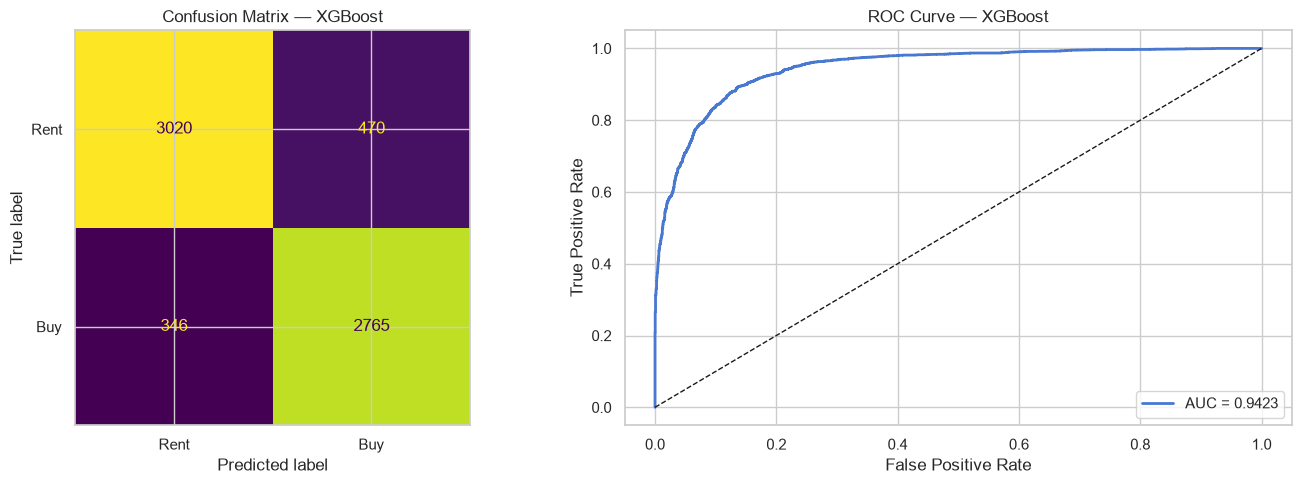

In [23]:
# Confusion matrix + ROC curve for the best classifier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_te, best_clf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rent', 'Buy']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_clf_name}', fontsize=12)

fpr, tpr, _ = roc_curve(y_te, best_clf_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {best_clf_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {best_clf_name}', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [24]:
# ── Bridge: Build regression_metrics & all_predictions for Section 14 ───────
regression_metrics = []
for _mname, _m in results.items():
    regression_metrics.append({
        'segment':   'Buy',
        'model':     _mname,
        'R2':        _m['test_r2'],
        'CV_R2':     _m['cv_r2_mean'],
        'CV_R2_std': _m['cv_r2_std'],
        'Train_R2':  _m['train_r2'],
        'Gap':       _m['overfit_gap'],
        'RMSE':      _m['rmse_egp'],
        'MAE':       _m['mae_egp'],
    })

_best_preds = results[best_name]['y_pred_real']
_test_meta  = df_clean.loc[X_test.index]

def _safe_col(df, col, fallback):
    return df[col].values if col in df.columns else fallback

_pred_frame = pd.DataFrame({
    'listing_id':      _safe_col(_test_meta, 'listing_id',    X_test.index),
    'offering_type':   'Buy',
    'city':            _safe_col(_test_meta, 'city',          np.nan),
    'property_type':   _safe_col(_test_meta, 'property_type', np.nan),
    'actual_price':    y_test_real.values,
    'predicted_price': _best_preds,
    'residual':        _best_preds - y_test_real.values,
    'segment':         'Buy',
    'model':           best_name,
})
all_predictions = [_pred_frame]

print(f'✓ regression_metrics : {len(regression_metrics)} models  (segment="Buy")')
print(f'✓ all_predictions    : {len(all_predictions[0]):,} rows  (best model = {best_name})')


✓ regression_metrics : 4 models  (segment="Buy")
✓ all_predictions    : 3,043 rows  (best model = XGBoost)


## 14. Metrics Summary & Exports

Print final metric tables and write results to disk.

Update the output paths below to match your local project structure.


In [25]:
print('── Regression Metrics ──')
regression_metrics = globals().get('regression_metrics', [])
if regression_metrics:
    reg_summary = pd.DataFrame(regression_metrics)
    display(reg_summary.sort_values(['segment', 'R2'], ascending=[True, False]))
else:
    print('Regression metrics not available yet. Run Part C first.')

print('\n── Classification Metrics ──')
clf_summary = pd.DataFrame(clf_metrics)
display(clf_summary.sort_values('ROC_AUC', ascending=False))


── Regression Metrics ──


,segment,model,R2,CV_R2,CV_R2_std,Train_R2,Gap,RMSE,MAE
2,Buy,XGBoost,0.7710,0.7452,0.0095,0.9371,0.1661,26447.0,14570.0
3,Buy,LightGBM,0.7705,0.7391,0.0096,0.9220,0.1516,26154.0,14619.0
1,Buy,RandomForest,0.7382,0.7041,0.0142,0.8620,0.1238,26808.0,15330.0
0,Buy,Ridge,0.5007,0.4625,0.0215,0.4796,-0.0211,35210.0,21936.0



── Classification Metrics ──


,model,Accuracy,F1,ROC_AUC,CV_AUC,Train_AUC,Gap
2,XGBoost,0.876382,0.876472,0.945676,0.942312,0.944589,-0.001087
0,LogisticRegression,0.859415,0.859457,0.938294,0.935082,0.936133,-0.002161
1,RandomForest,0.848659,0.848575,0.934272,0.929333,0.931399,-0.002873


In [26]:
# ── Update these paths to match your environment ─────────────────────────────
OUT_PREDICTIONS  = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_predictions.csv'
OUT_FI           = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\feature_importance.csv'

# Export predictions
pred_df = pd.concat(all_predictions, ignore_index=True)

clf_test = df_ml.loc[idx_te, ['listing_id']].copy()
clf_test['predicted_type'] = np.where(best_clf_pred == 1, 'Buy', 'Rent')
clf_map = clf_test.set_index('listing_id')['predicted_type']
pred_df['predicted_type'] = pred_df['listing_id'].map(clf_map)

EXPORT_CORE = ['listing_id', 'offering_type', 'city', 'property_type',
               'actual_price', 'predicted_price', 'residual', 'predicted_type']
export_cols = [c for c in EXPORT_CORE + FEATURES if c in pred_df.columns]
pred_df[export_cols].to_csv(OUT_PREDICTIONS, index=False)
print(f'✓ Saved predictions        → {len(pred_df):,} rows')

# Export feature importance
fi_df = pd.DataFrame(all_fi_records)
fi_df.to_csv(OUT_FI, index=False)
print(f'✓ Saved feature importance → {len(fi_df):,} rows')


✓ Saved predictions        → 3,043 rows
✓ Saved feature importance → 58 rows


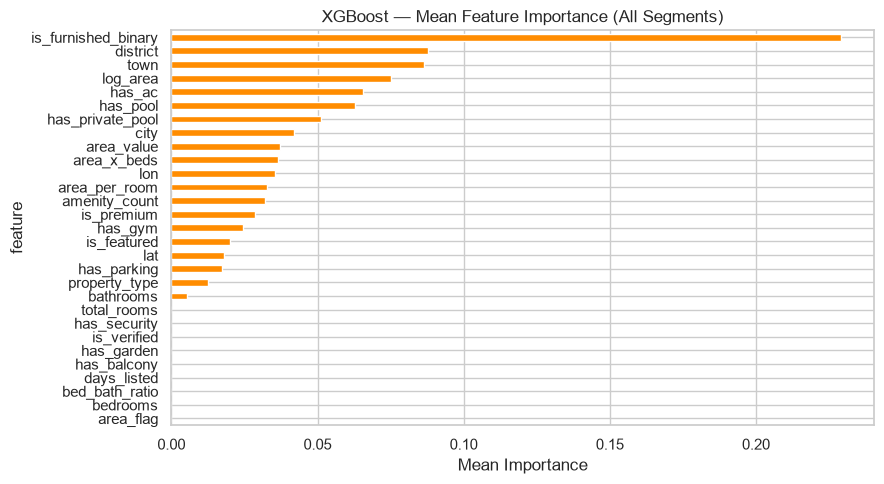

In [27]:
# XGBoost feature importance averaged across all segments
xgb_fi = fi_df[fi_df['model'] == 'XGBoost']

if not xgb_fi.empty:
    mean_fi = xgb_fi.groupby('feature')['importance'].mean().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    mean_fi.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('XGBoost — Mean Feature Importance (All Segments)', fontsize=12)
    ax.set_xlabel('Mean Importance')
    plt.tight_layout()
    plt.show()
